In [1]:
from pynq import Overlay
ol = Overlay("ns_filter_bd_wrapper.bit")
print(list(ol.ip_dict.keys()))

['axi_dma_0', 'ns_filter_0', 'processing_system7_0']


In [1]:
exec(open('hw_run_ns.py').read())

=== Validating frame_014_qp160_prelr.yuv ===
Loaded pre-LR + HR : 1080x1920, uint8
Training NS taps (chunked accumulator + KKT + 7-bit CD)...
  train time: 25.61 s
  taps (int7):      [2, 1, -7, 1, 1, -4, 15, -5, 0, -5, 14, 63]
  weighted_sum_int: 89
  norm_q16:         0x02E0  (736)
  CD passes: 2, improvements: 1
Running on FPGA...
  HW: 34.2 ms, beats=2062084, tlast=1
Applying same taps in Python (golden)...
  Python apply: 4.66 s
HW vs Python golden:
  max |diff|:  254
  mean |diff|: 20.394
  exact match: 15.49%
PSNR vs HR (interior only):
  pre-LR   : 26.850 dB   (baseline)
  HW NS    : 17.286 dB   (delta: -9.564)
  Python NS: 26.956 dB   (delta: +0.105)


In [10]:
import numpy as np

# Identity: only center = 32, norm = exactly 2048 (DC gain = 1 exactly)
taps_id = np.array([0]*11 + [32], dtype=np.int8)
norm_id = 2048

# Use the same pre-LR frame you already have loaded
H, W = 1080, 1920
prelr = np.fromfile("/home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_PRELR/RANGE_1/frame_014_qp160_prelr.yuv",
                    dtype=np.uint8).reshape(H, W)

hw_out = run_hw_frame(ns, dma, prelr, taps_id, norm_id)     # (H-6, W)

# Compare to input rows 3..H-4, cols 3..W-4 (skip border garbage)
expected = prelr[3:H-3, 3:W-3]
got      = hw_out[:, 3:W-3]
diff = got.astype(np.int16) - expected.astype(np.int16)

print(f"Identity bit-accuracy:")
print(f"  max |diff|:  {int(np.abs(diff).max())}")
print(f"  mean |diff|: {float(np.abs(diff).mean()):.4f}")
print(f"  exact match: {float((diff == 0).mean())*100:.2f}%")

Found 90 pre-LR files:
  /home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_PRELR/RANGE_1/frame_021_qp170_prelr.yuv
  /home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_PRELR/RANGE_1/frame_106_qp160_prelr.yuv
  /home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_PRELR/RANGE_1/frame_023_qp170_prelr.yuv
  /home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_PRELR/RANGE_1/frame_096_qp170_prelr.yuv
  /home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_PRELR/RANGE_1/frame_014_qp160_prelr.yuv
  /home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_PRELR/RANGE_1/frame_074_qp170_prelr.yuv
  /home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_PRELR/RANGE_1/frame_085_qp180_prelr.yuv
  /home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_PRELR/RANGE_1/frame_045_qp160_pre

In [11]:
# Only pair 6 = 10, everything else = 0.
# Pair 6 should be (dr=-1, dc=0) + (dr=+1, dc=0) per RTL mapping.
# For DC gain 1: norm = round(65536 / (2*10)) = 3277
taps_p6 = np.array([0,0,0,0,0,0, 10, 0,0,0,0, 0], dtype=np.int8)
norm_p6 = 3277

# Delta image: single 255 pixel at (500, 500), rest = 0
img = np.zeros((H, W), dtype=np.uint8)
img[500, 500] = 255

hw_out = run_hw_frame(ns, dma, img, taps_p6, norm_p6)   # (H-6, W)

# The impulse (255) at (500, 500) should produce nonzero output at exactly
# TWO positions: where a pair member landed on it.
# For pair 6 = (dr=-1) + (dr=+1), output nonzero at:
#   (500 - (-1), 500) = (501, 500)   AND   (500 - 1, 500) = (499, 500)
# Both should have value ~ 10 * 255 * 3277 / 65536 = ~ 127

nonzero_rows, nonzero_cols = np.where(hw_out > 0)
print(f"Number of nonzero output pixels: {len(nonzero_rows)}")
print(f"First 10 nonzero locations:")
for r, c in zip(nonzero_rows[:10], nonzero_cols[:10]):
    # HW output row 0 corresponds to input row 3
    print(f"  hw_out[{r},{c}] = {hw_out[r,c]}   (input coords: r={r+3}, c={c})")

Loaded: /home/xilinx/jupyter_notebooks/pc_filter/TreesAndGrass_1920_1080_30fps_8bit/TEST_PRELR/RANGE_1/frame_021_qp170_prelr.yuv
Shape:  (1080, 1920)   dtype: uint8
Range:  min=0  max=255   mean=114.9


In [2]:
# Sharpener: taps = -2 for all pairs, center = 50, DC gain = 6, norm = 10923
taps = [(-2) & 0x7F] * 11 + [50]
for i, t in enumerate(taps):
    ns.write(i*4, t)
ns.write(0x30, 0x2AAB)

H, W = H_IMG, W_IMG                # must match compiled FRAME_W = 1920
ns.write(0x34, W)
ns.write(0x38, H)

print(f"frame configured: {ns.read(0x08)} x {ns.read(0x0C)}")

NameError: name 'H_IMG' is not defined

In [13]:
from pynq import allocate

in_buf  = allocate(shape=(H*W,),     dtype=np.uint32)   # 8.3 MB
out_buf = allocate(shape=((H-6)*W,), dtype=np.uint32)   # 8.2 MB
in_buf[:] = img.flatten().astype(np.uint32)             # pixel in low byte

print(f"Input  size: {in_buf.nbytes:>10,} bytes")
print(f"Output size: {out_buf.nbytes:>10,} bytes")
print(f"Expected output beats: {(H-6)*W:,}")

Input  size:  8,294,400 bytes
Output size:  8,248,320 bytes
Expected output beats: 2,062,080


In [14]:
import time

def reset_dma():
    mmap = dma.mmio
    mmap.write(0x00, 0x4); mmap.write(0x30, 0x4)
    time.sleep(0.01)
    mmap.write(0x00, 0x1); mmap.write(0x30, 0x1)
    dma.sendchannel._first_transfer = True
    dma.recvchannel._first_transfer = True

reset_dma()

t0 = time.time()
dma.recvchannel.transfer(out_buf)
ns.write(0x3C, 1)
dma.sendchannel.transfer(in_buf)
dma.sendchannel.wait()
dma.recvchannel.wait()
t1 = time.time()

beats = ns.read(0x00)
flags = ns.read(0x04)
print(f"Time: {(t1-t0)*1000:.1f} ms")
print(f"beats: {beats}   expected: {(H-6)*W}   tlast_fired: {(flags>>3)&1}")
print(f"throughput: {(H*W)/(t1-t0)/1e6:.1f} Mpixels/s")

Time: 37.0 ms
beats: 2062084   expected: 2062080   tlast_fired: 1
throughput: 56.0 Mpixels/s


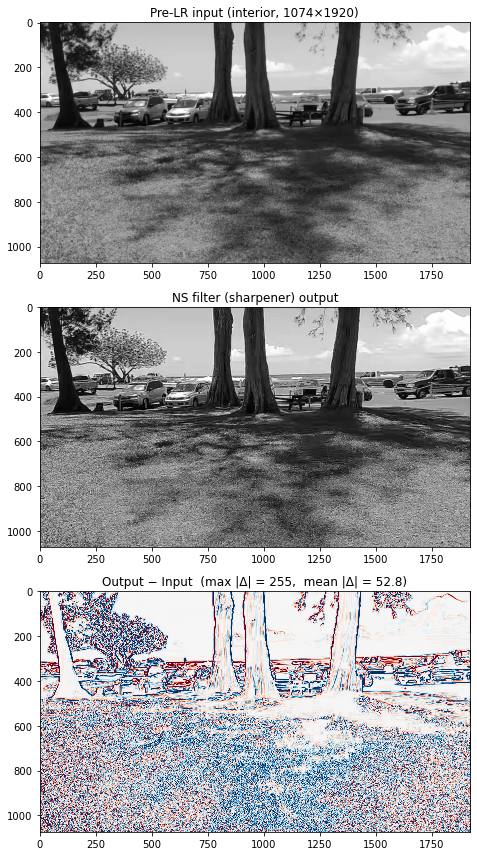

In [15]:
import matplotlib.pyplot as plt

out_img = (out_buf & 0xFF).reshape((H-6, W)).astype(np.uint8)
in_interior = img[3:H-3, :]                       # rows the filter actually processed

diff = out_img.astype(np.int16) - in_interior.astype(np.int16)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
axes[0].imshow(in_interior, cmap='gray')
axes[0].set_title(f"Pre-LR input (interior, {H-6}×{W})")
axes[1].imshow(out_img, cmap='gray')
axes[1].set_title("NS filter (sharpener) output")
axes[2].imshow(diff, cmap='RdBu', vmin=-40, vmax=40)
axes[2].set_title(f"Output − Input  (max |Δ| = {np.abs(diff).max()},  mean |Δ| = {np.abs(diff).mean():.1f})")
plt.tight_layout()
plt.show()

In [8]:
del in_buf
del out_buf